## Feature Engineering and PCA

**Goal:** Create useful features from the raw columns, then study PCA.


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_validate, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import Ridge, LinearRegression
from sklearn.ensemble import RandomForestRegressor, HistGradientBoostingRegressor
from sklearn.dummy import DummyRegressor


In [10]:
def make_one_hot_encoder():
    """Compatibility helper for different scikit-learn versions."""
    try:
        return OneHotEncoder(handle_unknown='ignore', sparse_output=False)
    except TypeError:
        return OneHotEncoder(handle_unknown='ignore', sparse=False)

train = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\train_basic.csv')
test = pd.read_csv(r'C:\Users\divin\OneDrive\Desktop\Data_Science\project\UK_House_Price_Prediction_Model\test_basic.csv')

print('Loaded train_basic:', train.shape)
print('Loaded test_basic:', test.shape)

Loaded train_basic: (1460, 81)
Loaded test_basic: (1459, 80)



| Raw columns | Engineered feature | Why useful? |
|---|---|---|
| `YrSold`, `YearBuilt` | `HouseAge` | Buyers care about how old the house is. |
| `YrSold`, `YearRemodAdd` | `RemodAge` | Recent remodels may increase value. |
| Basement + floor areas | `TotalSF` | Total usable size is easier for a model to learn. |
| Full and half bathrooms | `TotalBathrooms` | One number summarises bathroom availability. |
| Garage/basement/pool/fireplace columns | `HasGarage`, etc. | Binary feature showing whether the house has that facility. |

In [11]:
def add_house_features(df):
    df = df.copy()
    df['HouseAge'] = df['YrSold'] - df['YearBuilt']
    df['RemodAge'] = df['YrSold'] - df['YearRemodAdd']
    df['TotalSF'] = df['TotalBsmtSF'].fillna(0) + df['1stFlrSF'].fillna(0) + df['2ndFlrSF'].fillna(0)
    df['TotalBathrooms'] = (
        df['FullBath'].fillna(0) + 0.5 * df['HalfBath'].fillna(0) +
        df['BsmtFullBath'].fillna(0) + 0.5 * df['BsmtHalfBath'].fillna(0)
    )
    df['TotalPorchSF'] = (
        df['OpenPorchSF'].fillna(0) + df['EnclosedPorch'].fillna(0) +
        df['3SsnPorch'].fillna(0) + df['ScreenPorch'].fillna(0)
    )
    df['HasGarage'] = (df['GarageArea'].fillna(0) > 0).astype(int)
    df['HasBasement'] = (df['TotalBsmtSF'].fillna(0) > 0).astype(int)
    df['HasFireplace'] = (df['Fireplaces'].fillna(0) > 0).astype(int)
    df['HasPool'] = (df['PoolArea'].fillna(0) > 0).astype(int)
    return df

train_fe = add_house_features(train)
test_fe = add_house_features(test)

train_fe.to_csv(
    'C:/Users/divin/OneDrive/Desktop/Data_Science/project/UK_House_Price_Prediction_Model/train_features.csv',
    index=False
)

test_fe.to_csv(
    'C:/Users/divin/OneDrive/Desktop/Data_Science/project/UK_House_Price_Prediction_Model/test_features.csv',
     index=False)

print(train_fe[['SalePrice','HouseAge','RemodAge','TotalSF','TotalBathrooms','HasGarage','HasBasement','HasFireplace','HasPool']].head())

   SalePrice  HouseAge  RemodAge  TotalSF  TotalBathrooms  HasGarage  \
0     208500         5         5     2566             3.5          1   
1     181500        31        31     2524             2.5          1   
2     223500         7         6     2706             3.5          1   
3     140000        91        36     2473             2.0          1   
4     250000         8         8     3343             3.5          1   

   HasBasement  HasFireplace  HasPool  
0            1             0        0  
1            1             1        0  
2            1             1        0  
3            1             1        0  
4            1             1        0  


compare engineered features with SalePrice using correlation and plots

SalePrice         1.000000
TotalSF           0.782260
TotalBathrooms    0.631731
HasFireplace      0.471908
HasGarage         0.236832
TotalPorchSF      0.195739
HasBasement       0.152829
HasPool           0.093708
RemodAge         -0.509079
HouseAge         -0.523350
Name: SalePrice, dtype: float64

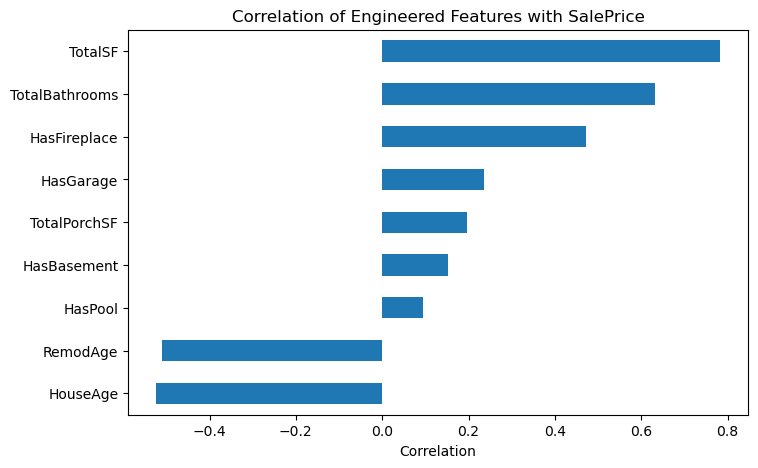

In [12]:
engineered_cols = ['HouseAge', 'RemodAge', 'TotalSF', 'TotalBathrooms', 'TotalPorchSF', 'HasGarage', 'HasBasement', 'HasFireplace', 'HasPool']
engineered_corr = train_fe[engineered_cols + ['SalePrice']].corr()['SalePrice'].sort_values(ascending=False)
display(engineered_corr)

plt.figure(figsize=(8, 5))
engineered_corr.drop('SalePrice').sort_values().plot(kind='barh')
plt.title('Correlation of Engineered Features with SalePrice')
plt.xlabel('Correlation')
plt.show()

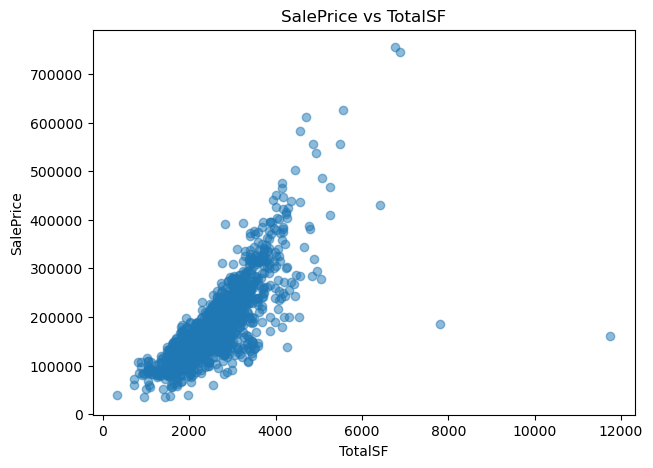

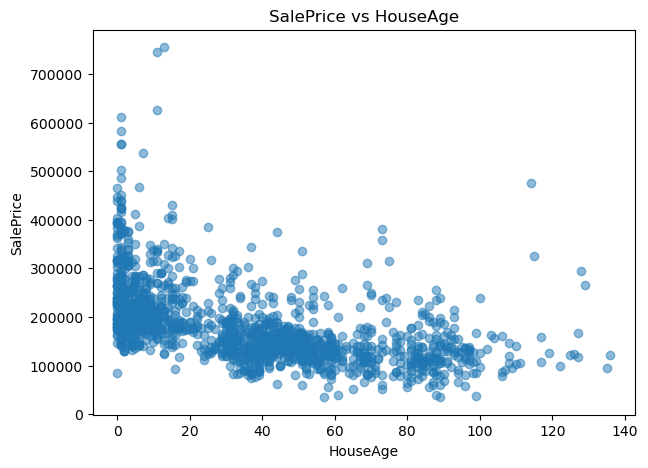

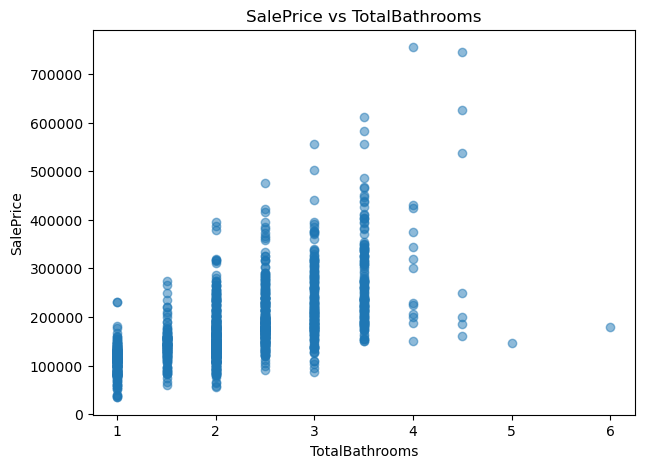

In [13]:
for col in ['TotalSF', 'HouseAge', 'TotalBathrooms']:
    plt.figure(figsize=(7, 5))
    plt.scatter(train_fe[col], train_fe['SalePrice'], alpha=0.5)
    plt.title(f'SalePrice vs {col}')
    plt.xlabel(col)
    plt.ylabel('SalePrice')
    plt.show()

#### Prepare data for PCA

Numeric features: median imputation + scaling.
Categorical features: missing value imputation + one-hot encoding

In [14]:
y = np.log1p(train_fe['SalePrice'])
X = train_fe.drop(columns=['SalePrice', 'Id'])

numeric_features = X.select_dtypes(include=np.number).columns.tolist()
categorical_features = X.select_dtypes(exclude=np.number).columns.tolist()

numeric_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='Missing')),
    ('onehot', make_one_hot_encoder())
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_pipeline, numeric_features),
    ('cat', categorical_pipeline, categorical_features)
])

X_train, X_valid, y_train, y_valid = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print('Original feature columns:', X.shape[1])
print('Numeric columns:', len(numeric_features))

Original feature columns: 88
Numeric columns: 45


#### Why scaling before PCA?

PCA is affected by the size/range of values.

Without scaling, a large-number column like `LotArea` could dominate smaller columns like `GarageCars`.

That is why `StandardScaler` is used before PCA.

#### PCA explained variance

PCA creates new features called **principal components**.

`n_components=0.95` means:

> Keep enough components to preserve 95% of the variance/information in the preprocessed data.

In [16]:
pca_pipeline = Pipeline(steps=[
    ('preprocess', preprocessor),
    ('pca', PCA(n_components=0.95, random_state=42))
])

X_train_pca = pca_pipeline.fit_transform(X_train)
preprocessed_shape = pca_pipeline.named_steps['preprocess'].transform(X_train).shape

print('Feature count after preprocessing:', preprocessed_shape[1])
print('PCA components kept:', X_train_pca.shape[1])
print('Explained variance kept:', round(pca_pipeline.named_steps['pca'].explained_variance_ratio_.sum(), 4))

Feature count after preprocessing: 310
PCA components kept: 74
Explained variance kept: 0.951


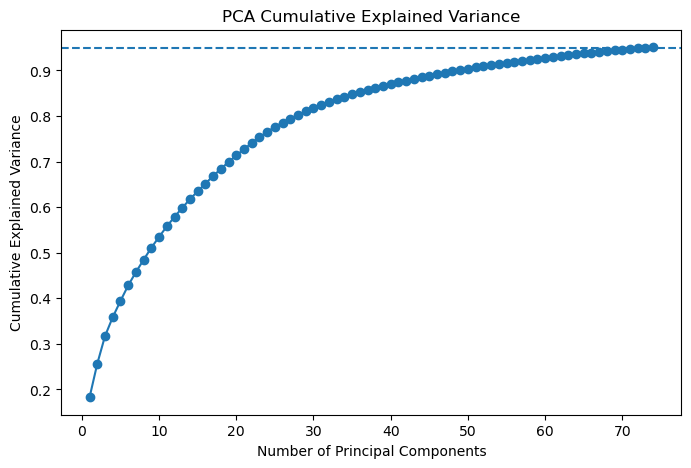

In [17]:
explained = np.cumsum(pca_pipeline.named_steps['pca'].explained_variance_ratio_)
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(explained) + 1), explained, marker='o')
plt.axhline(0.95, linestyle='--')
plt.title('PCA Cumulative Explained Variance')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.show()

- Created engineered features such as `HouseAge`, `TotalSF`, and `TotalBathrooms`.
- Saved `train_features.csv` and `test_features.csv`.
- Built preprocessing for numeric and categorical columns.
- Applied PCA after preprocessing.
- Checked how many principal components are needed to retain 95% variance.

- Created engineered features such as `HouseAge`, `TotalSF`, and `TotalBathrooms`.
- Saved `train_features.csv` and `test_features.csv`.
- Built preprocessing for numeric and categorical columns.
- Applied PCA after preprocessing.
- Checked how many principal components are needed to retain 95% variance.